In [6]:
import os, sys, importlib

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


In [7]:
def add_trajectory_metrics(df):
    def compute(gr):
        gr = gr.sort_values("hours").copy()
        gr["d_eff"] = gr["effector_score"].diff()
        gr["d_reg"] = gr["reg_score"].diff()
        gr["dt"]    = gr["hours"].diff()

        gr["step_distance"] = np.sqrt(gr["d_eff"]**2 + gr["d_reg"]**2)
        gr["speed_per_hour"] = gr["step_distance"] / gr["dt"].replace(0, np.nan)
        gr["angle_rad"] = np.arctan2(gr["d_reg"], gr["d_eff"])
        return gr

    return df.groupby(["donor", "guide"], group_keys=False).apply(
        compute,
        include_groups=False,
    )


In [8]:
from analysis_utils.module_pipeline import build_module_trajectory_table
df_traj = build_module_trajectory_table()
df_traj.head()



Saved enriched trajectory table → /Users/acastano/Desktop/crispr_carT_AI_analysis/results/modules/metadata_with_modules_and_trajectories.csv


/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/module_pipeline.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["donor", "guide"], group_keys=False).apply(compute)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,donor,effector_score,reg_score,d_eff,d_reg,dt,step_distance,speed_per_hour,angle_rad,PC_quadrant
CART0077_RNAseq_NgsRun1_001,-37.723277,-31.705538,-12.123623,-2.744340,-15.144212,-9.991624,-3.412902,7.700148,-5.771141,2.742833,...,CART0077_D1,-1.012198,0.248009,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_002,-39.836363,-31.833348,-10.900892,-3.312477,-15.591511,-8.813367,-3.750231,9.619637,-6.636606,4.066675,...,CART0077_D1,-1.048841,0.432601,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_003,-31.637766,-29.746144,-17.107666,-0.723304,-11.271251,-9.780588,12.959361,-2.573610,-3.644878,-2.881499,...,CART0077_D2,-0.847401,0.053121,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_004,-40.140399,-31.899786,-12.068343,-3.726443,-14.294023,-6.180032,12.564387,3.884865,-7.805759,2.527802,...,CART0077_D2,-0.996135,-0.082484,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_005,-40.540445,-32.856847,-10.222355,-8.728795,-22.326515,12.585187,-1.935315,-1.552674,-10.996653,2.630127,...,CART0077_D3,-1.177432,0.650719,NaN,NaN,NaN,NaN,NaN,NaN,Q2: Eff- / Reg+


In [9]:
df_traj = build_module_trajectory_table()
df_traj.head()


Saved enriched trajectory table → /Users/acastano/Desktop/crispr_carT_AI_analysis/results/modules/metadata_with_modules_and_trajectories.csv


/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/module_pipeline.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["donor", "guide"], group_keys=False).apply(compute)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,donor,effector_score,reg_score,d_eff,d_reg,dt,step_distance,speed_per_hour,angle_rad,PC_quadrant
CART0077_RNAseq_NgsRun1_001,-37.723277,-31.705538,-12.123623,-2.744340,-15.144212,-9.991624,-3.412902,7.700148,-5.771141,2.742833,...,CART0077_D1,-1.012198,0.248009,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_002,-39.836363,-31.833348,-10.900892,-3.312477,-15.591511,-8.813367,-3.750231,9.619637,-6.636606,4.066675,...,CART0077_D1,-1.048841,0.432601,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_003,-31.637766,-29.746144,-17.107666,-0.723304,-11.271251,-9.780588,12.959361,-2.573610,-3.644878,-2.881499,...,CART0077_D2,-0.847401,0.053121,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_004,-40.140399,-31.899786,-12.068343,-3.726443,-14.294023,-6.180032,12.564387,3.884865,-7.805759,2.527802,...,CART0077_D2,-0.996135,-0.082484,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_005,-40.540445,-32.856847,-10.222355,-8.728795,-22.326515,12.585187,-1.935315,-1.552674,-10.996653,2.630127,...,CART0077_D3,-1.177432,0.650719,NaN,NaN,NaN,NaN,NaN,NaN,Q2: Eff- / Reg+


In [10]:
df_traj.info()
df_traj.head()


<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, CART0077_RNAseq_NgsRun1_001 to CART0077_RNAseq_NgsRun1_060
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PC1               60 non-null     float64
 1   PC2               60 non-null     float64
 2   PC3               60 non-null     float64
 3   PC4               60 non-null     float64
 4   PC5               60 non-null     float64
 5   PC6               60 non-null     float64
 6   PC7               60 non-null     float64
 7   PC8               60 non-null     float64
 8   PC9               60 non-null     float64
 9   PC10              60 non-null     float64
 10  PC11              60 non-null     float64
 11  PC12              60 non-null     float64
 12  PC13              60 non-null     float64
 13  PC14              60 non-null     float64
 14  PC15              60 non-null     float64
 15  PC16              60 non-null     float64
 16  

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,donor,effector_score,reg_score,d_eff,d_reg,dt,step_distance,speed_per_hour,angle_rad,PC_quadrant
CART0077_RNAseq_NgsRun1_001,-37.723277,-31.705538,-12.123623,-2.744340,-15.144212,-9.991624,-3.412902,7.700148,-5.771141,2.742833,...,CART0077_D1,-1.012198,0.248009,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_002,-39.836363,-31.833348,-10.900892,-3.312477,-15.591511,-8.813367,-3.750231,9.619637,-6.636606,4.066675,...,CART0077_D1,-1.048841,0.432601,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_003,-31.637766,-29.746144,-17.107666,-0.723304,-11.271251,-9.780588,12.959361,-2.573610,-3.644878,-2.881499,...,CART0077_D2,-0.847401,0.053121,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_004,-40.140399,-31.899786,-12.068343,-3.726443,-14.294023,-6.180032,12.564387,3.884865,-7.805759,2.527802,...,CART0077_D2,-0.996135,-0.082484,NaN,NaN,NaN,NaN,NaN,NaN,Q3: Eff- / Reg-
CART0077_RNAseq_NgsRun1_005,-40.540445,-32.856847,-10.222355,-8.728795,-22.326515,12.585187,-1.935315,-1.552674,-10.996653,2.630127,...,CART0077_D3,-1.177432,0.650719,NaN,NaN,NaN,NaN,NaN,NaN,Q2: Eff- / Reg+


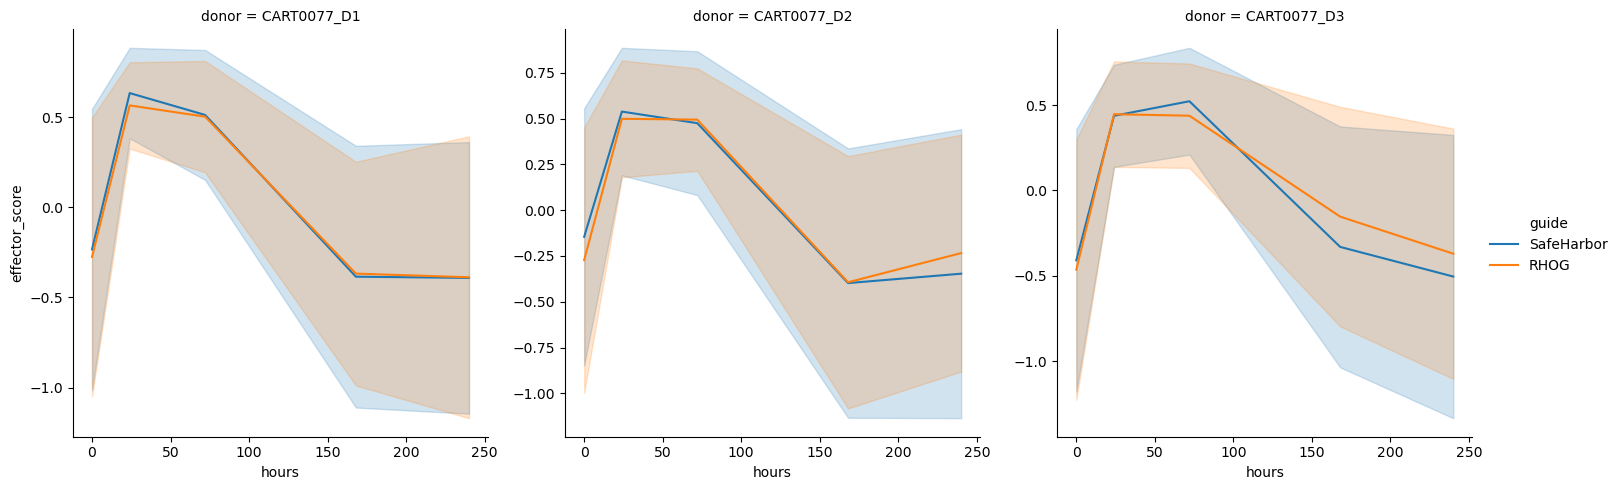

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    data=df_traj,
    x="hours",
    y="effector_score",
    hue="guide",
    col="donor",
    kind="line",
    facet_kws={"sharey": False, "sharex": True}
)
plt.show()


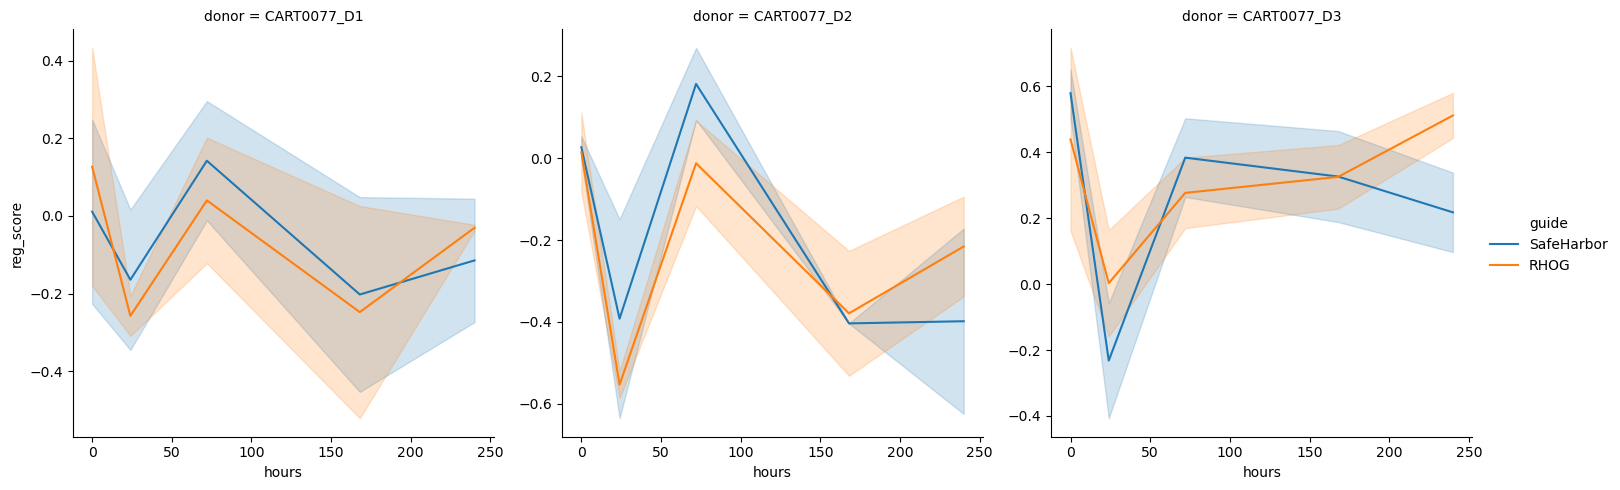

In [12]:
sns.relplot(
    data=df_traj,
    x="hours",
    y="reg_score",
    hue="guide",
    col="donor",
    kind="line",
    facet_kws={"sharey": False, "sharex": True}
)
plt.show()


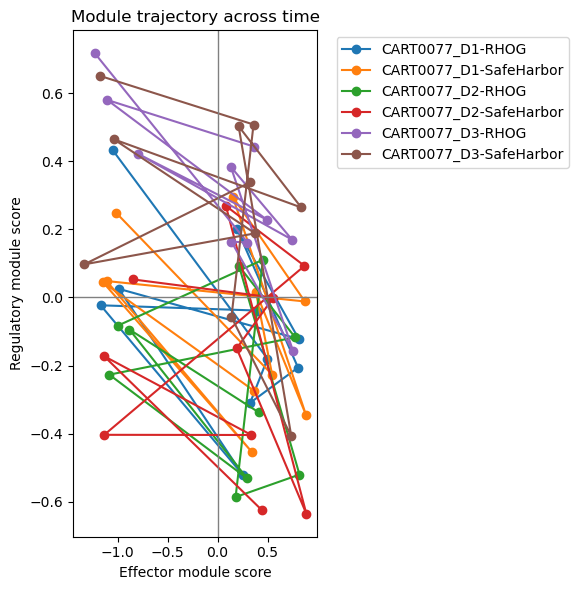

In [13]:
plt.figure(figsize=(6,6))

for (donor, guide), grp in df_traj.groupby(["donor", "guide"]):
    grp = grp.sort_values("hours")
    plt.plot(grp["effector_score"], grp["reg_score"], marker="o", label=f"{donor}-{guide}")

plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

plt.xlabel("Effector module score")
plt.ylabel("Regulatory module score")
plt.title("Module trajectory across time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [14]:
df_speed = (
    df_traj.groupby("guide")["speed_per_hour"]
    .mean()
    .sort_values(ascending=False)
)

df_speed


guide
SafeHarbor    0.020772
RHOG          0.017721
Name: speed_per_hour, dtype: float64

In [40]:
df_traj["PC_quadrant"].value_counts()


PC_quadrant
Q4: Eff+ / Reg-    22
Q3: Eff- / Reg-    17
Q2: Eff- / Reg+    12
Q1: Eff+ / Reg+     9
Name: count, dtype: int64

In [41]:
df_traj.groupby("guide")["PC_quadrant"].value_counts(normalize=True)


guide       PC_quadrant    
RHOG        Q4: Eff+ / Reg-    0.333333
            Q3: Eff- / Reg-    0.300000
            Q2: Eff- / Reg+    0.200000
            Q1: Eff+ / Reg+    0.166667
SafeHarbor  Q4: Eff+ / Reg-    0.400000
            Q3: Eff- / Reg-    0.266667
            Q2: Eff- / Reg+    0.200000
            Q1: Eff+ / Reg+    0.133333
Name: proportion, dtype: float64

In [42]:
import numpy as np

df_angles = (
    df_traj.groupby("guide")["angle_rad"]
    .mean()
    .sort_values()
)

df_angles


guide
SafeHarbor    0.229497
RHOG          0.536236
Name: angle_rad, dtype: float64

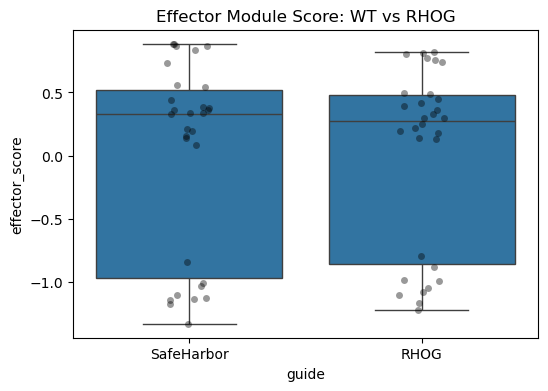

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_traj,
    x="guide",
    y="effector_score",
    order=["SafeHarbor", "RHOG"],
)
sns.stripplot(
    data=df_traj,
    x="guide",
    y="effector_score",
    order=["SafeHarbor", "RHOG"],
    color="black",
    alpha=0.4
)
plt.title("Effector Module Score: WT vs RHOG")
plt.show()


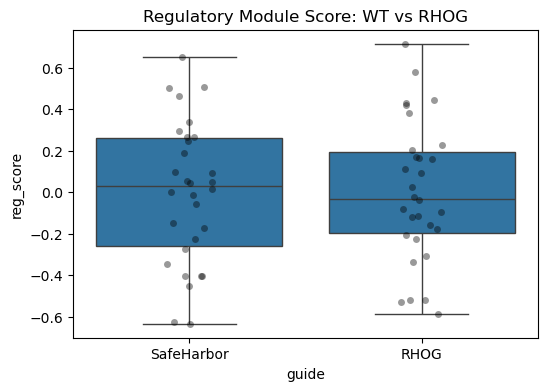

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_traj,
    x="guide",
    y="reg_score",
    order=["SafeHarbor", "RHOG"],
)
sns.stripplot(
    data=df_traj,
    x="guide",
    y="reg_score",
    order=["SafeHarbor", "RHOG"],
    color="black",
    alpha=0.4
)
plt.title("Regulatory Module Score: WT vs RHOG")
plt.show()


In [45]:
import scipy.stats as stats

wt_eff = df_traj[df_traj["guide"]=="SafeHarbor"]["effector_score"]
rhog_eff = df_traj[df_traj["guide"]=="RHOG"]["effector_score"]

wt_reg = df_traj[df_traj["guide"]=="SafeHarbor"]["reg_score"]
rhog_reg = df_traj[df_traj["guide"]=="RHOG"]["reg_score"]

print("Effector score difference p-value:", stats.ttest_ind(wt_eff, rhog_eff).pvalue)
print("Regulatory score difference p-value:", stats.ttest_ind(wt_reg, rhog_reg).pvalue)


Effector score difference p-value: 0.9857723129107172
Regulatory score difference p-value: 0.9518637289166229


In [46]:
effector_genes = ["PRF1", "GZMB", "NKG7", "CD8A", "CD8B", "IFNG", "TNF""IL2", "IFNG", "TNF", "CCL4","CCL5","IL6", "FAS"]

regulatory_genes = ["IL1RN", "FSTL3", "ARHGEF26", "SEC22C", "TRIM34"]

checkpoint_genes = ["PDCD1", "LAG3", "TIGIT", "CTLA4", "HAVCR2", "CD160"]


In [47]:
# expr_logcpm has genes × samples
expr_long = expr_logcpm.T  # samples × genes

# attach metadata
expr_with_meta = expr_long.join(meta, how="inner")


NameError: name 'expr_logcpm' is not defined

In [48]:
for gene in effector_genes:
    sns.boxplot(
        data=expr_with_meta,
        x="guide",
        y=gene,
        order=["SafeHarbor", "RHOG"]
    )
    sns.stripplot(
        data=expr_with_meta,
        x="guide",
        y=gene,
        order=["SafeHarbor", "RHOG"],
        color="black",
        alpha=0.4
    )
    plt.title(f"{gene}: expression WT vs RHOG")
    plt.show()

    wt = expr_with_meta[expr_with_meta["guide"]=="SafeHarbor"][gene]
    rhog = expr_with_meta[expr_with_meta["guide"]=="RHOG"][gene]
    p = stats.ttest_ind(wt, rhog).pvalue
    print(f"{gene} p-value: {p}")


NameError: name 'expr_with_meta' is not defined

In [49]:
from analysis_utils.config_utils import load_gene_sets

gene_sets = load_gene_sets("data/gene_sets/gene_sets.json")
gene_sets.keys()

ImportError: cannot import name 'load_gene_sets' from 'analysis_utils.config_utils' (/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/config_utils.py)